**Table of contents**<a id='toc0_'></a>    
- [01 - Classification](#toc1_)    
  - [11 - Machine learning with scikit-learn](#toc1_1_)    
  - [12 - The classification challenge](#toc1_2_)    
  - [13 - Measuring model performance](#toc1_3_)    
- [02 - Regression](#toc2_)    
  - [21 - Introduction to regression](#toc2_1_)    
  - [22 - The Basics of Linear Regression](#toc2_2_)    
  - [23 - Cross-validation](#toc2_3_)    
  - [24 - Regularized regression](#toc2_4_)    
- [03 - Fine-tuning your model](#toc3_)    
  - [31 - How good is your model?](#toc3_1_)    
  - [32 - Logistic Regression and the ROC curve](#toc3_2_)    
  - [33 - Hyperparameter tuning](#toc3_3_)    
- [04 - Preprocessing and Pipeline](#toc4_)    
  - [41 - Preprocessing data](#toc4_1_)    
  - [42 - Handling missing data](#toc4_2_)    
  - [43 - Centering and scaling](#toc4_3_)    
  - [44 - Evaluating multiple models](#toc4_4_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[01 - Classification](#toc0_)
[01 Classification](01%20Classification.pdf)
## <a id='toc1_1_'></a>[11 - Machine learning with scikit-learn](#toc0_)
- What is machine learning?
	- Machine learning is the process whereby: 
		- Computers are given the ability to learn to make decisions from data 
		- without being explicitly programmed! 
	- For example,
		- learning to predict whether an email is spam or not spam given its content and sender. 
		- Or learning to cluster books into different categories based on the words they contain, then assigning any new book to one of the existing clusters.
- Unsupervised learning
	- Uncovering hidden patterns from unlabeled data 
	- Example: 
		- Grouping customers into distinct categories (Clustering) 
- Supervised learning
	- The predicted values are known 
	- Aim: 
		- Predict the target values of unseen data, given the features 
	- Types of supervised learning
		- Classification: Target variable consists of categories
		- Regression: Target variable is continuous
- Naming conventions
	- Feature = predictor variable = independent variable 
	- Target variable = dependent variable = response variable 
- Before you use supervised learning
	- Requirements: 
		- No missing values 
		- Data in numeric format 
		- Data stored in pandas DataFrame or NumPy array 
	- Perform Exploratory Data Analysis (EDA) first 
## <a id='toc1_2_'></a>[12 - The classification challenge](#toc0_)
- Classifying labels of unseen data
	- Build a model 
	- Model learns from the labeled data (training data) we pass to it 
	- Pass unlabeled data to the model as input 
	- Model predicts the labels of the unseen/ unlabeled data
- k-Nearest Neighbors
	- an algorithm that is popular for classification problems
	- predict the label of a data point by 
		- Looking at the k closest labeled data points 
		- Taking a majority vote

In [30]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier 
churn_df = pd.read_csv("telecom_churn_clean.csv") 
X = churn_df[["total_day_charge", "total_eve_charge"]].values 
y = churn_df["churn"].values 
print(X.shape, y.shape) # examine data shape

knn = KNeighborsClassifier(n_neighbors=15) 
knn.fit(X, y) # fit on labeled data

# predicting on unlabeled data
X_new = np.array([[56.8, 17.5], 
    [24.4, 24.1], 
    [50.1, 10.9]])
print(X_new.shape) 

predictions = knn.predict(X_new)  
print('Predictions: {}'.format(predictions)) 

(3333, 2) (3333,)
(3, 2)
Predictions: [1 0 0]


## <a id='toc1_3_'></a>[13 - Measuring model performance](#toc0_)

- Measuring model performance
    - In classification, accuracy is a commonly used metric
    - Accuracy: $$\frac{correct \ predictions}{total \ observations}$$
    - How is accuracy measured?
    - Could compute accuracy on the data used to fit the classifier
    - NOT indicative of ability to generalize
- Model Complexity
    - Larger k = less complex model = can cause underfittin
    - Smaller k = more complex model = can lead to overfitting

In [31]:
# Train/test split
from sklearn.model_selection import train_test_split  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                 random_state=21, stratify=y)  
knn = KNeighborsClassifier(n_neighbors=6)
knn.fit(X_train, y_train) 
print(knn.score(X_test, y_test)) 

0.872


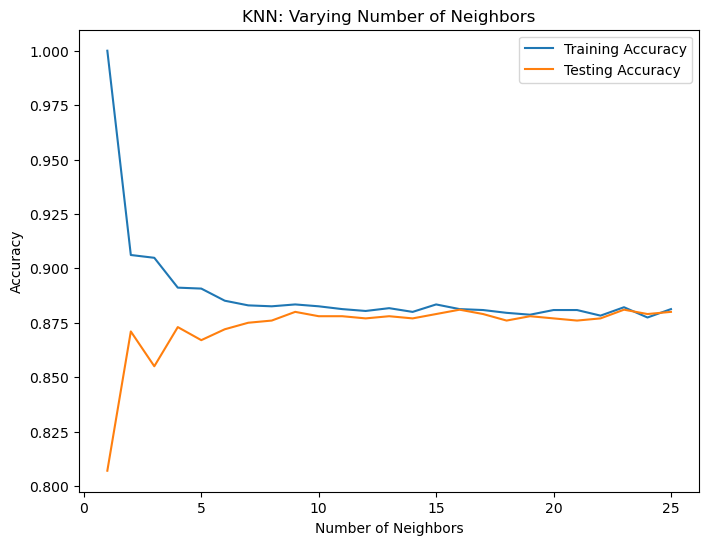

In [32]:
# Model complexity and over/underfitting
train_accuracies = {} 
test_accuracies = {} 
neighbors = np.arange(1, 26) 
for k in neighbors: 
    knn = KNeighborsClassifier(n_neighbors=k) 
    knn.fit(X_train, y_train) 
    train_accuracies[k] = knn.score(X_train, y_train) 
    test_accuracies[k] = knn.score(X_test, y_test)
#plotting the results
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6)) 
plt.title("KNN: Varying Number of Neighbors") 
plt.plot(neighbors, train_accuracies.values(), label="Training Accuracy") 
plt.plot(neighbors, test_accuracies.values(), label="Testing Accuracy") 
plt.legend() 
plt.xlabel("Number of Neighbors") 
plt.ylabel("Accuracy") 
plt.show()

# <a id='toc2_'></a>[02 - Regression](#toc0_)
[02 Regression.pdf](02%20Regression.pdf)
## <a id='toc2_1_'></a>[21 - Introduction to regression](#toc0_)
-  In regression tasks, the target variable typically has continuous values, such as a country's GDP, or the price of a house.
- Example: 
    - Predicting blood glucose levels examining
    - It contains features including 
        - number of pregnancies, triceps skinfold measurements, insulin levels, body mass index, known as BMI, age in years, 
        - and diabetes status, with one indicating a diagnosis, and zero representing the absence of a diagnosis.
- Steps to implement simple LR
    - creating feature and target arrays from the dataframe X and y
    - LR predicts based on one single feature, so needs to single out one feature, in this case X_bmi, it also has to be 2D array to be accepted by scikit-learn
    - Plotting to examine distribution
    - Fitting a regression model

   pregnancies  glucose  diastolic  triceps  insulin   bmi    dpf  age  \
0            6      148         72       35        0  33.6  0.627   50   
1            1       85         66       29        0  26.6  0.351   31   
2            8      183         64        0        0  23.3  0.672   32   
3            1       89         66       23       94  28.1  0.167   21   
4            0      137         40       35      168  43.1  2.288   33   

   diabetes  
0         1  
1         0  
2         1  
3         0  
4         1  
<class 'numpy.ndarray'> <class 'numpy.ndarray'>


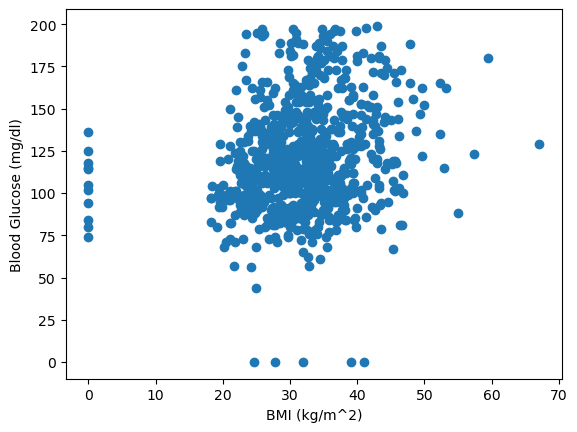

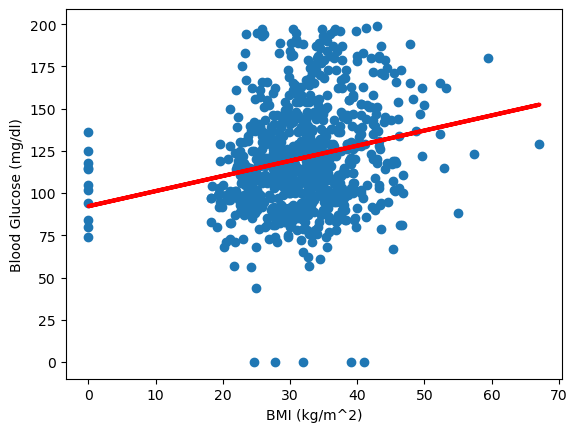

In [33]:
# example data 
import pandas as pd
diabetes_df = pd.read_csv("diabetes_clean.csv") 
print(diabetes_df.head()) 
X = diabetes_df.drop("glucose", axis=1).values 
y = diabetes_df["glucose"].values   
print(type(X), type(y))
X_bmi = X[:, 4]
X_bmi = X_bmi.reshape(-1, 1) # reshape to 2D array

# plotting glocose vs. bmi
import matplotlib.pyplot as plt
plt.scatter(X_bmi, y)
plt.ylabel("Blood Glucose (mg/dl)")
plt.xlabel("BMI (kg/m^2)")
plt.show()

# fitting a regression model
from sklearn.linear_model import LinearRegression
linreg = LinearRegression()
linreg.fit(X_bmi, y)
predictions = linreg.predict(X_bmi)
plt.scatter(X_bmi, y)
plt.plot(X_bmi, predictions, color='red', linewidth=3)
plt.ylabel("Blood Glucose (mg/dl)")
plt.xlabel("BMI (kg/m^2)")
plt.show()

## <a id='toc2_2_'></a>[22 - The Basics of Linear Regression](#toc0_)
- Regression mechanics
    - $ y = ax + b$
        - y = target variable
        - x = single feature
        - a,b = parameters/ coefficients of the model or slope/ intercept
    - How are a and b chosen?
        - Defne an error function for any given line
        - Choose the line that minimizes the error function
    - Error function = loss function = cost function
- The loss function
    - We want the LR line to be as close to the observations as possible, meaning we want to minize the vertical distance between the fit and the data points 
    - For each observation, we calculate the distance between it and line, called residual
    - To avoid negative residuals to cancel out positive residuals while summing, we square all residuals and sum them up, called residual sum of squares RSS
- Ordinary Least Squares (OLS) $$ RSS = \sum_{i=1}^n (y_i - \hat{y}_i)^2 $$
    - the residual sum of squares (RSS) is the sum of the squares of residuals. It is a measure of the discrepancy between the data and an estimation model
    - OLS is a method for estimating the unknown parameters in a linear regression model
    - the goal of OLS is to minize RSS
- Linear regression in higher dimensions
    - $ y = a_1x_1 + a_2x_2 + b$
    - To fit a linear regression model here:
        - Need to specify 3 variables: $a_1, a_2 , b$
    - In higher dimensions:
        - Known as multiple regression
        - Must specify coefficients for each feature and the variable $$ y = a_1x_1 + a_2x_2 + ... + a_nx_n + b$$
    - scikit-learn works exactly the same way:
        - Pass two arrays: features and target
- R-squared ($R^2$):
    - quantifies the variance in target valuesexplained by the features
    - Values range from 0 to 1
    - the higher $R^2$ the more accurate
- Mean squared error (MSE) and root mean squared error (RMSE)
    - MSE is measured in target units, squared $$ MSE = \frac12\sum_{i=1}^n (y_i - \hat{y}_i)^2$$
    - Measure RMSE in the same units at the target variable $$ RMSE = \sqrt{MSE}$$


In [34]:
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression   
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                                    random_state=42)   
reg_all = LinearRegression()  
reg_all.fit(X_train, y_train)  
y_pred = reg_all.predict(X_test) 

print(reg_all.score(X_test, y_test)) # R^2 score
from sklearn.metrics import root_mean_squared_error  
root_mean_squared_error(y_test, y_pred) 


0.28280468810375103


26.341459582232265

## <a id='toc2_3_'></a>[23 - Cross-validation](#toc0_)
- Cross-validation motivatio
    - Model performance is dependent on the way we split up the data
    - Not representative of the model's ability to generalize to unseen data
    - Solution: Cross-validation!
- Cross-validation basics - 5-fold CV example
    - Begin with splitting the dataset into 5 folds 
    - set aside the first fold as a test set, fit and compute metrics
    - Next, set the second fold as the test set, and move on to the next steps for 5 times in total
    - We have 5 sets of metrics
- More folds does not always mean better results, can be computationally expensive and splitting the data into too small folds could make it meaningless 

In [35]:
from sklearn.model_selection import cross_val_score, KFold  
kf = KFold(n_splits=6, shuffle=True, random_state=42)  
reg = LinearRegression()  
cv_results = cross_val_score(reg, X, y, cv=kf) 
print(cv_results)
print("Mean R^2: {}".format(np.mean(cv_results)))
print("Standard Deviation of R^2: {}".format(np.std(cv_results)))
print("95% Confidence Interval: {}".format(np.quantile(cv_results, [0.025, 0.975]))) # 95% confidence interval

[0.26207548 0.28228176 0.41203082 0.23785884 0.41634629 0.30398869]
Mean R^2: 0.31909697867344794
Standard Deviation of R^2: 0.07015320610114224
95% Confidence Interval: [0.24088592 0.41580685]


## <a id='toc2_4_'></a>[24 - Regularized regression](#toc0_)
- Why regularize?
    - Recall: Linear regression minimizes a loss function
    - It chooses a coefficient, a, for each feature variable, plus b
    - Large coefficients can lead to overfitting
    - Regularization means to penalize large coefficients
- Ridge regression
    - Loss function = OLS loss function + $$ \alpha * \sum_{i=1}^na^2_i $$
    - Ridge penalizes large positive or negative coefficients
    - $\alpha$: parameter we need to choose
    - picking $\alpha$ is similar to picking k in KNN
    - it's known as a Hyperparameter: variable used to optimize model parameters
    - $\alpha$ controls model complexity
        - $\alpha$ = 0 = OLS (can lead to overfitting)
        - High $\alpha$ can lead to underfitting
- Lasso regression
    - Loss function = OLS loss function + $$ \alpha * \sum_{i=1}^n|a_i|$$ 
- Lasso regression for feature selection
    - Lasso can select important features of a dataset
    - Shrinks the coefficients of less important features to zero
    - Features not shrunk to zero are selected by lasso

[0.28284666232222233, 0.28320633574804754, 0.2853000732200003, 0.26423984812668133, 0.19292424694100963]
[0.2831114455475573, 0.29795609755827845, 0.17989838789273882, 0.18127361610181136, 0.15679544303617987]


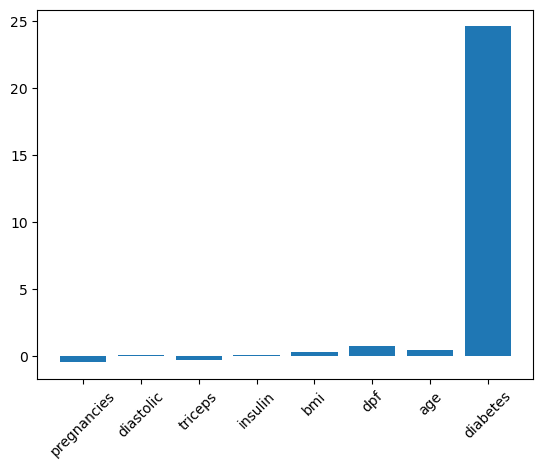

In [36]:
# Ridge regression in scikit-learn
from sklearn.linear_model import Ridge
scores_ridge = []
for alpha in [0.1, 1.0, 10.0, 100.0, 1000.0]:  
    ridge = Ridge(alpha=alpha)  
    ridge.fit(X_train, y_train)    
    y_pred = ridge.predict(X_test)  
    scores_ridge.append(ridge.score(X_test, y_test))  
print(scores_ridge)

# Lasso regression in scikit-learn
from sklearn.linear_model import Lasso
scores_lasso = []
for alpha in [0.01, 1.0, 10.0, 20.0, 50.0]:  
    lasso = Lasso(alpha=alpha)  
    lasso.fit(X_train, y_train)    
    lasso_pred = lasso.predict(X_test)  
    scores_lasso.append(lasso.score(X_test, y_test))  
print(scores_lasso)

# Lasso for feature selection in scikit-learn
from sklearn.linear_model import Lasso
X = diabetes_df.drop("glucose", axis=1).values 
y = diabetes_df["glucose"].values 
names = diabetes_df.drop("glucose", axis=1).columns  
lasso = Lasso(alpha=0.1)  
lasso_coef = lasso.fit(X, y).coef_  
plt.bar(names, lasso_coef) 
plt.xticks(rotation=45) 
plt.show() 


# <a id='toc3_'></a>[03 - Fine-tuning your model](#toc0_)
[03 Fine-tuning your model.pdf](03%20Fine-tuning%20your%20model.pdf)
## <a id='toc3_1_'></a>[31 - How good is your model?](#toc0_)
- Classification metrics
    - Measuring model performance with accuracy:
        - Fraction of correctly classified samples
        - Not always a useful metric
- Class imbalance
    - Classification for predicting fraudulent bank transactions
        - 99% of transactions are legitimate; 1% are fraudulent
    - Could build a classifier that predicts NONE of the transactions are fraudulent
        - 99% accurate!
        - But terrible at actually predicting fraudulent transactionsFails at its original purpose
    - Class imbalance: Uneven frequency of classes
    - Need a different way to assess performance
- Confusion matrix for assessing classificationperformance
    - Accuracy: $$ \frac{TP + TN}{TP + TN + FP + FN} $$
    - Precision: $$ \frac{True Positives}{True Positives  + False Positives} $$
        - High precision = lower false positive rate
        - High precision: Not many legitimate transactions are predicted to be fraudulent
    - Recall : $$ \frac{True Positives}{True Positives  + False Negatives} $$
        - High recall = lower false negative rate
        - High recall: Predicted most fraudulent transactions correctly
    - F1 Score (Overall): $$ 2 \times \frac{precision \times recall}{precision  + recall}$$
        - The F1-score is the harmonic mean of precision and recall.
        - The F1 score favors models with similar precision and recall, and is a useful metric if we are seeking a model which performs reasonably well across both metrics.

In [37]:
from sklearn.metrics import classification_report, confusion_matrix  
df_2 = pd.read_csv("telecom_churn_clean.csv")
X = df_2[["total_day_charge", "total_eve_charge"]].values
y = df_2["churn"].values
knn = KNeighborsClassifier(n_neighbors=7)  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4,
                             random_state=42)   
knn.fit(X_train, y_train) 
y_pred = knn.predict(X_test) 

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred)) 

[[1111   27]
 [ 142   54]]
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      1138
           1       0.67      0.28      0.39       196

    accuracy                           0.87      1334
   macro avg       0.78      0.63      0.66      1334
weighted avg       0.85      0.87      0.85      1334



## <a id='toc3_2_'></a>[32 - Logistic Regression and the ROC curve](#toc0_)
- Logistic regression for binary classification
    - Logistic regression is used for classification problems
    - Logistic regression outputs probabilities
    - If the probability,  p > 0.5:
        - The data is labeled  1
    - If the probability,  p < 0.5:
        - The data is labeled  0
- Probability thresholds
    - By default, logistic regression threshold = 0.5
    - Not specific to logistic regression
        - KNN classifiers also have thresholds
    - What happens if we vary the threshold?
- The ROC Curve:
    - We can use a receiver operating characteristic, or ROC curve, to visualize how different thresholds affect true positive and false positive rates. 
    - the dotted line represents a chance model, which randomly guesses labels.
    - When the threshold equals zero, 
        - the model predicts one for all observations, 
            - meaning it will correctly predict all positive values, 
            - and incorrectly predict all negative values.
    - If the threshold equals one, 
        - the model predicts zero for all data, 
        - which means that both true and false positive rates are zero
    - If the thresholds vary, we get a series of different false positive and true positive rates.
- ROC AUC:
    - If we have a model with one for true positive rate and zero for false positive rate, this would be the perfect model.
    - Therefore, we calculate the area under the ROC curve, a metric known as AUC.
    - Scores range from zero to one, with one being ideal.
        - Here, the model scores point-six-seven, which is only 34% better than a model making random guesses.

0.18826020038112795


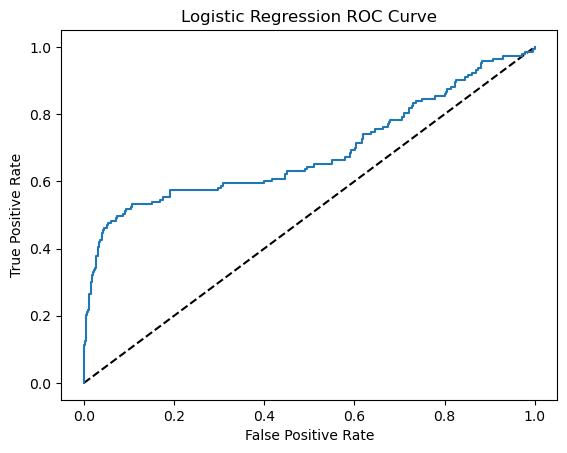

ROC AUC Score: 0.6870364174914934


In [38]:
from sklearn.linear_model import LogisticRegression  
logreg = LogisticRegression()  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)   
logreg.fit(X_train, y_train) 
y_pred = logreg.predict(X_test) 
# Get the probability of the positive class
y_pred_probs = logreg.predict_proba(X_test)[:, 1]  
print(y_pred_probs[0]) 

# plotting ROC Curve
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
plt.plot([0, 1], [0, 1], 'k--') 
plt.plot(fpr, tpr) 
plt.xlabel('False Positive Rate') 
plt.ylabel('True Positive Rate') 
plt.title('Logistic Regression ROC Curve') 
plt.show()
from sklearn.metrics import roc_auc_score  
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_probs)) 

## <a id='toc3_3_'></a>[33 - Hyperparameter tuning](#toc0_)
- Hyperparameter tuning:
    - Ridge/lasso regression: Choosing `alpha`
    - KNN: Choosing `n_neighbors`
    - Hyperparameters: Parameters we specify before fitting the model
        - Like `alpha` and `n_neighbors`
- Steps to choose the correct hyperparameters (aka hyperparameter tuning):
    1. Try lots of different hyperparameter values
    2.  Fit all of them separately
    3.  See how well they perform
    4.  Choose the best performing values
- How to properly tune hyperparameters:
    - It is essential to use cross-validation to avoid overfitting to the test set
    - We can still split the data and perform cross-validation on the training set
    - We withhold the test set for final evaluation
- Grid search cross-validaton:
    - Choose a grid of possible hyperparameter values to try
    -  Limitations and an alternative approach:
        - 3-fold cross-validation, 1 hyperparameter, 10 total values = 30 fits
        - 10 fold cross-validation, 3 hyperparameters, 30 total values = 900 fits -> it does not scale well
- RandomizedSearchCV
    - picks random hyperparameter values rather than exhaustively searching through all options
    - `n_iter` argument sets the number of iterations of searching


In [39]:
# GridSearchCV for hyperparameter tuning
from sklearn.model_selection import GridSearchCV  
kf = KFold(n_splits=5, shuffle=True, random_state=42)  
param_grid = {"alpha": np.arange(0.0001, 1, 10),
                        "solver": ["sag", "lsqr"]}   
ridge = Ridge() 
ridge_cv = GridSearchCV(ridge, param_grid, cv=kf)  
ridge_cv.fit(X_train, y_train) 
print(ridge_cv.best_params_, ridge_cv.best_score_) 

# RandomizedSearchCV for hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV
random_paramgrid = {"alpha": np.arange(0.0001, 1, 10),
                     "solver": ["sag", "lsqr"]}
ridge_rand = Ridge()
ridge_rand_cv = RandomizedSearchCV(ridge_rand, random_paramgrid, cv=kf, n_iter=2, random_state=42)  
ridge_rand_cv.fit(X_train, y_train)
print(ridge_rand_cv.best_params_, ridge_rand_cv.best_score_)
test_score = ridge_rand_cv.score(X_test, y_test)
print("Test Score: {}".format(test_score))

{'alpha': np.float64(0.0001), 'solver': 'lsqr'} 0.03525257192862687
{'solver': 'lsqr', 'alpha': np.float64(0.0001)} 0.03525257192862687
Test Score: 0.0690106317528395


# <a id='toc4_'></a>[04 - Preprocessing and Pipeline](#toc0_)
[04 Preprocessing and Pipeline.pdf](04%20Preprocessing%20and%20Pipeline.pdf)
## <a id='toc4_1_'></a>[41 - Preprocessing data](#toc0_)
- scikit-learn requirements
    - Numeric data
    - No missing values 
    - With real-world data:
        - This is rarely the case
        - We will often need to preprocess our data first
- Dealing with categorical feature:
    - scikit-learn will not accept categorical features by default
    - Need to convert categorical features into numeric values
    - Convert the categorical features into multiple binary features called dummy variables
        - 0: Observation was NOT that category
        - 1: Observation was that category
- Dealing with categorical features in Python:
    - scikit-learn: `OneHotEncoder()`
    - pandas: `get_dummies()`
- Music dataset:
    - `popularity`: Target
    - `genre`: Categorical feature


In [40]:
music_df = pd.read_csv("music_clean.csv")
music_df.head()
music_dummies = pd.get_dummies(music_df, drop_first=True)
print(music_dummies.head())
music_dummies = pd.concat([music_df, music_dummies], axis=1)
music_dummies = music_dummies.drop(["genre"], axis=1)
# LR with dummy variables
from sklearn.model_selection import cross_val_score, KFold 
from sklearn.linear_model import LinearRegression
X = music_dummies.drop("popularity", axis=1).values
y = music_dummies["popularity"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
linreg = LinearRegression()
linreg_cv_results = cross_val_score(linreg, X_train, y_train, cv=kf, scoring = "neg_mean_squared_error")
print(np.sqrt(-linreg_cv_results)) # RMSE for each fold



   Unnamed: 0  popularity  acousticness  danceability  duration_ms  energy  \
0       36506        60.0      0.896000         0.726     214547.0   0.177   
1       37591        63.0      0.003840         0.635     190448.0   0.908   
2       37658        59.0      0.000075         0.352     456320.0   0.956   
3       36060        54.0      0.945000         0.488     352280.0   0.326   
4       35710        55.0      0.245000         0.667     273693.0   0.647   

   instrumentalness  liveness  loudness  speechiness    tempo  valence  genre  
0          0.000002    0.1160   -14.824       0.0353   92.934    0.618      1  
1          0.083400    0.2390    -4.795       0.0563  110.012    0.637      1  
2          0.020300    0.1250    -3.634       0.1490  122.897    0.228      1  
3          0.015700    0.1190   -12.020       0.0328  106.063    0.323      1  
4          0.000297    0.0633    -7.787       0.0487  143.995    0.300      1  
[11.2470961  10.85674186 10.10529394 10.62244254 11

## <a id='toc4_2_'></a>[42 - Handling missing data](#toc0_)
- Missing data
    - No value for a feature in a particular row
    - This can occur because:
        - There may have been no observation
        - The data might be corrupt
    - We need to deal with missing data
- Dropping missing data
    - remove missing observations accounting for less than 5% of all data.
    - or remove columns with 55-60% missing data
- Imputing values
    - Imputation - use subject-matter expertise to replace missing data with educated guesses
    - Common to use the mean (bad practice)
    - Can also use the median, or another value
    - For categorical values, we typically use the most frequent value - the mode
    - Must split our data first, to avoid data leakage
- Impute using a pipeline:
    - A pipeline is an object used to run a series of transformations and build a model in a single workflow. 
    - To build a pipeline 
        - we construct a list of steps containing tuples with the step names specified as strings, 
        - and instantiate the transformer or model.

In [41]:
# drop rows with missing values in the columns of interest
music_df = music_df.dropna(subset=["genre", "popularity", "loudness", "liveness", "tempo"])  
print(music_df.isna().sum().sort_values()) 

# Imputing missing values with SimpleImputer
from sklearn.impute import SimpleImputer 
X_cat = music_df["genre"].values.reshape(-1,1)
X_num = music_df.drop(["genre", "popularity"], axis=1).values
y = music_df["popularity"].values
X_train_cat, X_test_cat, y_train, y_test = train_test_split(X_cat, y, test_size=0.2, random_state=42)
X_train_num, X_test_num, _, _ = train_test_split(X_num, y, test_size=0.2, random_state=42)
imp_cat = SimpleImputer(strategy="most_frequent")
X_train_cat_imp = imp_cat.fit_transform(X_train_cat)
X_test_cat_imp = imp_cat.transform(X_test_cat)

imp_num = SimpleImputer()
X_train_num_imp = imp_num.fit_transform(X_train_num)
X_test_num_imp = imp_num.transform(X_test_num)
X_train = np.append(X_train_cat_imp, X_train_num_imp, axis=1)
X_test = np.append(X_test_cat_imp, X_test_num_imp, axis=1)


Unnamed: 0          0
popularity          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
valence             0
genre               0
dtype: int64


In [42]:
# imputing with a pipeline
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer 

X = music_df.drop("genre", axis=1).values
y = music_df["genre"].values

steps = [("imputation", SimpleImputer()),
         ("logistic_regression", LogisticRegression())]
pipeline = Pipeline(steps)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
pipeline.fit(X_train, y_train)
pipeline.score(X_test, y_test)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8033333333333333

## <a id='toc4_3_'></a>[43 - Centering and scaling](#toc0_)
- Why scale our data?
    - Many models use some form of distance to inform them
    - Features on larger scales can disproportionately influence the model
        - Example: KNN uses distance explicitly when making predictions
    - We want features to be on a similar scale
    - Normalizing or standardizing (scaling and centering)
- How to scale our data
    - Subtract the mean and divide by variance
        - All features are centered around zero and have a variance of one
        - This is called *standardization*
    - Can also subtract the minimum and divide by the range
        - Minimum zero and maximum one
    - Can also normalize so the data ranges from -1 to +1
    - Other methods can be found in scikit-learn docs
- This section examines:
    - scaling in scikit-learn
    - scaling in a pipeline
    - comparing performance using unscaled data
    - CV and scaling in a pipeline

In [43]:
# scaling in scikit-learn
from sklearn.preprocessing import StandardScaler
X = music_df.drop("genre", axis=1).values
y = music_df["genre"].values
scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(np.mean(X), np.std(X))
print(np.mean(X_train_scaled), np.std(X_train_scaled))

20666.582585618085 68890.98734103922
3.5971225997855074e-16 0.9999999999999996


In [44]:
# scaling in a pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
steps = [("scaler", StandardScaler()),
         ("knn", KNeighborsClassifier(n_neighbors=6))]
pipeline = Pipeline(steps)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
knn_scaled = pipeline.fit(X_train, y_train)
y_pred_scaled = knn_scaled.predict(X_test)
print(knn_scaled.score(X_test, y_test))
# comparing performance of scaled vs. unscaled data
knn_unscaled = KNeighborsClassifier(n_neighbors=6)
knn_unscaled.fit(X_train, y_train)
y_pred_unscaled = knn_unscaled.predict(X_test)
print(knn_unscaled.score(X_test, y_test))

0.89
0.925


In [45]:
# CV and scaling in a pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV
steps = [("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier())]
pipeline = Pipeline(steps)
parameters = {"knn__n_neighbors": np.arange(1, 50)}
cv = GridSearchCV(pipeline, parameters, cv=5)
cv.fit(X_train, y_train)
y_pred_cv = cv.predict(X_test)
print(cv.best_params_, cv.best_score_)

{'knn__n_neighbors': np.int64(2)} 0.9287500000000002



## <a id='toc4_4_'></a>[44 - Evaluating multiple models](#toc0_)
- Different models for different problems (Some guiding principles)
    - Size of the dataset
        - Fewer features = simpler model, faster training time
        - Some models require large amounts of data to perform well
    - Interpretability
        - Some models are easier to explain, which can be important for stakeholders
        - Linear regression has high interpretability, as we can understand the coefficients
    - Flexibility
        - May improve accuracy, by making fewer assumptions about data
        - KNN is a more flexible model, doesn't assume any linear relationships
- It's all in the metrics
    - Regression model performance:
        - RMSE
        - R-squared
    - Classification model performance:
        - Accuracy
        - Confusion matrix
        - Precision, recall, F1-score
        - ROC AUC
    - one approach is 
        - to select several models and a metric, 
        - then evaluate their performance without any form of hyperparameter tuning
- A note on scaling
    - Models affected by scaling:
        - KNN
        - Linear Regression (plus Ridge, Lasso)
        - Logistic Regression
        - Artificial Neural Network 
    - Best to scale our data before evaluating models

/var/folders/j0/g3wk70ks28q5mg37slsr6w8w0000gn/T/ipykernel_16498/279165334.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results, labels=models.keys())


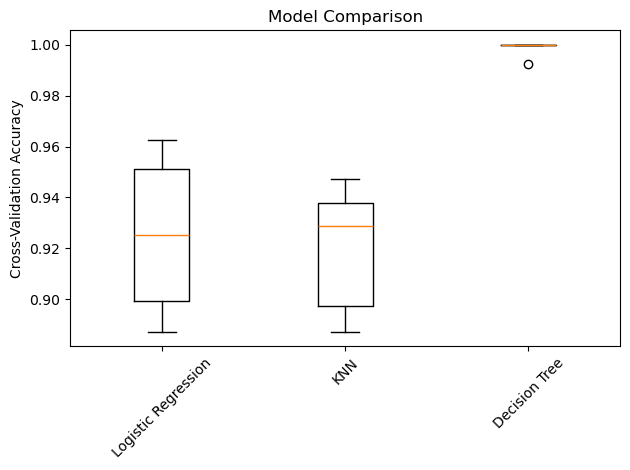

Logistic Regression Test Set Accuracy: 0.86
KNN Test Set Accuracy: 0.875
Decision Tree Test Set Accuracy: 1.0


In [46]:
# Eval classification models
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

music_df = pd.read_csv("music_clean.csv")
X = music_df.drop("genre", axis=1).values
y = music_df["genre"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {"Logistic Regression": LogisticRegression(),
          "KNN": KNeighborsClassifier(),
          "Decision Tree": DecisionTreeClassifier()}
results = []

for model in models.values():
    kf = KFold(n_splits=6, shuffle=True, random_state=42)
    cv_results = cross_val_score(model, X_train_scaled, y_train, cv=kf)
    results.append(cv_results)

plt.boxplot(results, labels=models.keys())
plt.title("Model Comparison")
plt.ylabel("Cross-Validation Accuracy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# test set performance
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    test_score = model.score(X_test_scaled, y_test)
    print("{} Test Set Accuracy: {}".format(name, test_score))

